#### Temporal split, rolling backtesting и baseline-модели

In [2]:
import pandas as pd
import numpy as np

In [3]:
DATE_COL = "rep_date"
COUNTRY_COL = "country"
HS_COL = "hs"
TARGET_COL = "value"

STATIC_COUNTRY_COLS = [
    "distw",
    "unfriendly",
    "brics",
    "cis"
]

COUNTRY_TIME_COLS = [
    "sanctions_proxy",
    "sanctions_proxy_smooth",
    "cpi_yoy",
    "ip_yoy",
    "ex_yoy",
    "logistics_exposure_distw"
]

GLOBAL_TIME_COLS = [
    "gscpi",
    "cb_full_import_value",
    "usd_rub",
    "gov_earn_from_import_nds",
    "gov_expendings"
]

OPTIONAL_EXISTING_COLS = [
    "post_sanctions",
    "unfriendly_post",
    "brics_post",
    "cis_post"
]

SANCTIONS_START = pd.Timestamp("2022-02-01")

TARGET_LAGS = [1, 2, 3, 6, 12]
TARGET_ROLL_WINDOWS = [3, 6, 12]

DYNAMIC_LAGS = [1, 3, 6, 12]
DYNAMIC_ROLL_WINDOWS = [3, 6]

MIN_HISTORY_STRICT = 12

In [4]:
model_df_h1_strict = pd.read_excel('data/after_clean_lags_and_rolling_data.xlsx')

In [5]:
def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.sum(np.abs(y_true))
    if denom == 0:
        return np.nan
    return np.sum(np.abs(y_true - y_pred)) / denom

def smape(y_true, y_pred, eps=1e-9):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred) + eps
    return np.mean(2 * np.abs(y_true - y_pred) / denom)

def compute_metrics(y_true, y_pred):
    return {
        "MAE": mae(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "WAPE": wape(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred)
    }

#### Генератор rolling-origin фолдов

Здесь мы делаем схему вида:

* train до определенного месяца,
* validation = следующий месяц или следующий блок месяцев,
* потом окно сдвигается вперед.

In [6]:
def make_rolling_folds(
    df: pd.DataFrame,
    date_col: str = DATE_COL,
    horizon: int = 1,
    first_validation_month: str = "2024-01-01",
    last_validation_month: str = "2025-06-01",
    step_months: int = 1
):
    """
    Создает rolling-origin folds.
    Для каждого validation month train использует все данные строго раньше него.
    """
    data = df.copy()
    data[date_col] = pd.to_datetime(data[date_col])

    first_val = pd.Timestamp(first_validation_month)
    last_val = pd.Timestamp(last_validation_month)

    val_months = pd.date_range(first_val, last_val, freq=f"{step_months}MS")

    folds = []

    for val_month in val_months:
        train_end = val_month - pd.offsets.MonthBegin(1)

        fold = {
            "train_end": train_end,
            "val_start": val_month,
            "val_end": val_month
        }
        folds.append(fold)

    return folds

#### Применение split к modeling table

In [8]:
def get_fold_data(
    df: pd.DataFrame,
    fold: dict,
    horizon: int = 1,
    date_col: str = DATE_COL
):
    """
    Разделяет данные на train и validation по target_date_h{horizon}.
    Это правильнее, чем делить по rep_date.
    """
    data = df.copy()
    target_date_col = f"target_date_h{horizon}"

    train_mask = data[target_date_col] <= fold["train_end"]
    val_mask = (
        (data[target_date_col] >= fold["val_start"]) &
        (data[target_date_col] <= fold["val_end"])
    )

    train_df = data.loc[train_mask].copy()
    val_df = data.loc[val_mask].copy()

    return train_df, val_df

#### Простые baseline-модели для панели

In [9]:
def predict_baseline_last_value(df: pd.DataFrame):
    return df[f"{TARGET_COL}_lag1"].values

def predict_baseline_seasonal_naive(df: pd.DataFrame):
    return df[f"{TARGET_COL}_lag12"].values

def predict_baseline_rollmean3(df: pd.DataFrame):
    return df[f"{TARGET_COL}_rollmean_3"].values

def predict_baseline_rollmean6(df: pd.DataFrame):
    return df[f"{TARGET_COL}_rollmean_6"].values

#### Универсальная оценка baseline-а на одном фолде

In [10]:
def evaluate_single_baseline_on_fold(
    val_df: pd.DataFrame,
    predictor_func,
    horizon: int = 1
):
    target_col = f"target_h{horizon}"

    tmp = val_df.copy()
    tmp["y_pred"] = predictor_func(tmp)

    # На случай NaN в baseline features
    tmp = tmp[tmp["y_pred"].notna()].copy()

    y_true = tmp[target_col].values
    y_pred = tmp["y_pred"].values

    metrics = compute_metrics(y_true, y_pred)
    metrics["n_obs"] = len(tmp)

    return metrics

#### Оценка всех baseline-моделей на всех фолдах


In [11]:
def run_panel_baseline_backtest(
    df: pd.DataFrame,
    folds: list,
    horizon: int = 1
):
    baseline_funcs = {
        "last_value": predict_baseline_last_value,
        "seasonal_naive_12": predict_baseline_seasonal_naive,
        "rollmean_3": predict_baseline_rollmean3,
        "rollmean_6": predict_baseline_rollmean6
    }

    results = []

    for i, fold in enumerate(folds, start=1):
        train_df, val_df = get_fold_data(df, fold, horizon=horizon)

        for model_name, func in baseline_funcs.items():
            metrics = evaluate_single_baseline_on_fold(val_df, func, horizon=horizon)

            row = {
                "fold_id": i,
                "model": model_name,
                "train_end": fold["train_end"],
                "val_start": fold["val_start"],
                "val_end": fold["val_end"],
                **metrics
            }
            results.append(row)

    results_df = pd.DataFrame(results)
    return results_df

#### Сводка по baseline-моделям

In [12]:
def summarize_backtest_results(results_df: pd.DataFrame):
    summary = (
        results_df.groupby("model", as_index=False)[["MAE", "RMSE", "WAPE", "sMAPE", "n_obs"]]
        .mean()
        .sort_values("WAPE")
        .reset_index(drop=True)
    )
    return summary

#### Запуск panel backtest

In [13]:
folds_h1 = make_rolling_folds(
    model_df_h1_strict,
    horizon=1,
    first_validation_month="2024-01-01",
    last_validation_month="2025-06-01",
    step_months=1
)

baseline_results_h1 = run_panel_baseline_backtest(
    model_df_h1_strict,
    folds=folds_h1,
    horizon=1
)

baseline_summary_h1 = summarize_backtest_results(baseline_results_h1)

print(baseline_summary_h1)
baseline_results_h1.head()

               model            MAE          RMSE      WAPE     sMAPE  n_obs
0         rollmean_6  241452.598066  1.248763e+06  0.365929  0.589858  621.0
1         rollmean_3  244356.927951  1.274367e+06  0.371161  0.505279  621.0
2         last_value  307151.115039  1.655309e+06  0.464537  0.443444  621.0
3  seasonal_naive_12  351171.986588  1.679482e+06  0.529171  0.554344  621.0


,fold_id,model,train_end,val_start,val_end,MAE,RMSE,WAPE,sMAPE,n_obs
0,1,last_value,2023-12-01,2024-01-01,2024-01-01,426393.855878,1.906744e+06,0.753509,0.531490,621
1,1,seasonal_naive_12,2023-12-01,2024-01-01,2024-01-01,553857.597133,2.523877e+06,0.978759,0.706335,621
2,1,rollmean_3,2023-12-01,2024-01-01,2024-01-01,368957.316022,1.523961e+06,0.652009,0.621651,621
3,1,rollmean_6,2023-12-01,2024-01-01,2024-01-01,291909.206759,1.113800e+06,0.515853,0.663446,621
4,2,last_value,2024-01-01,2024-02-01,2024-02-01,557298.398867,2.779678e+06,0.874424,0.503464,621


Для оценки качества прогнозных моделей использовалась схема временной валидации, исключающая случайное перемешивание наблюдений. Поскольку задача имеет выраженную временную структуру, применение стандартного random split приводило бы к искаженной оценке predictive performance за счет использования информации из будущих периодов. Поэтому в исследовании была использована rolling-origin backtesting procedure, при которой для каждого validation month модель обучается только на данных, доступных до соответствующего момента времени.

Поскольку supervised-постановка была задана через прогноз целевой переменной на горизонт h месяцев вперед, разделение на обучающие и валидационные выборки проводилось по дате прогнозируемого значения, а не по исходной дате наблюдения. Такой подход обеспечивает корректную оценку one-step-ahead forecasting accuracy и соответствует реалистичному сценарию практического использования модели.

В качестве базовых ориентиров были использованы несколько простых panel-level forecasting baselines: прогноз по последнему наблюдаемому значению, сезонный naive forecast на основе годового лага, а также прогнозы на основе скользящего среднего за последние 3 и 6 месяцев. Эти модели позволяют проверить, насколько сильны инерция, сезонность и краткосрочное сглаживание в динамике импорта медицинского оборудования.

In [14]:
def run_panel_baseline_backtest_with_preds(
    df: pd.DataFrame,
    folds: list,
    horizon: int = 1
):
    baseline_funcs = {
        "last_value": predict_baseline_last_value,
        "seasonal_naive_12": predict_baseline_seasonal_naive,
        "rollmean_3": predict_baseline_rollmean3,
        "rollmean_6": predict_baseline_rollmean6
    }

    metrics_rows = []
    pred_rows = []

    target_col = f"target_h{horizon}"
    target_date_col = f"target_date_h{horizon}"

    for i, fold in enumerate(folds, start=1):
        train_df, val_df = get_fold_data(df, fold, horizon=horizon)

        for model_name, func in baseline_funcs.items():
            tmp = val_df.copy()
            tmp["y_pred"] = func(tmp)

            # убираем строки, где baseline не может дать прогноз
            tmp = tmp[tmp["y_pred"].notna()].copy()

            if len(tmp) == 0:
                continue

            y_true = tmp[target_col].values
            y_pred = tmp["y_pred"].values

            metrics = compute_metrics(y_true, y_pred)
            metrics_rows.append({
                "fold_id": i,
                "model": model_name,
                "train_end": fold["train_end"],
                "val_start": fold["val_start"],
                "val_end": fold["val_end"],
                "n_obs": len(tmp),
                **metrics
            })

            keep_cols = [
                DATE_COL,
                target_date_col,
                "series_id",
                "country",
                "hs"
            ]
            keep_cols = [c for c in keep_cols if c in tmp.columns]

            pred_part = tmp[keep_cols].copy()
            pred_part["fold_id"] = i
            pred_part["model"] = model_name
            pred_part["y_true"] = tmp[target_col].values
            pred_part["y_pred"] = tmp["y_pred"].values

            pred_rows.append(pred_part)

    metrics_df = pd.DataFrame(metrics_rows)
    preds_df = pd.concat(pred_rows, ignore_index=True) if pred_rows else pd.DataFrame()

    return metrics_df, preds_df

In [15]:
folds_h1 = make_rolling_folds(
    model_df_h1_strict,
    horizon=1,
    first_validation_month="2024-01-01",
    last_validation_month="2025-06-01",
    step_months=1
)

baseline_results_h1, baseline_preds_h1 = run_panel_baseline_backtest_with_preds(
    model_df_h1_strict,
    folds=folds_h1,
    horizon=1
)

baseline_summary_h1 = summarize_backtest_results(baseline_results_h1)

print(baseline_summary_h1)
baseline_preds_h1.head()

               model            MAE          RMSE      WAPE     sMAPE  n_obs
0         rollmean_6  241452.598066  1.248763e+06  0.365929  0.589858  621.0
1         rollmean_3  244356.927951  1.274367e+06  0.371161  0.505279  621.0
2         last_value  307151.115039  1.655309e+06  0.464537  0.443444  621.0
3  seasonal_naive_12  351171.986588  1.679482e+06  0.529171  0.554344  621.0


,rep_date,target_date_h1,series_id,country,hs,fold_id,model,y_true,y_pred
0,2023-12-01,2024-01-01,Albania__9018,Albania,9018,1,last_value,0.0,0.0
1,2023-12-01,2024-01-01,Albania__9019,Albania,9019,1,last_value,0.0,0.0
2,2023-12-01,2024-01-01,Albania__9020,Albania,9020,1,last_value,0.0,0.0
3,2023-12-01,2024-01-01,Albania__9021,Albania,9021,1,last_value,0.0,0.0
4,2023-12-01,2024-01-01,Albania__9022,Albania,9022,1,last_value,0.0,0.0


In [16]:
target_date_col = "target_date_h1"

agg_preds_h1 = (
    baseline_preds_h1
    .groupby(["model", target_date_col], as_index=False)[["y_true", "y_pred"]]
    .sum()
    .sort_values(["model", target_date_col])
)

agg_preds_h1.head()

,model,target_date_h1,y_true,y_pred
0,last_value,2024-01-01,3.514098e+08,5.487113e+08
1,last_value,2024-02-01,3.957832e+08,5.775624e+08
2,last_value,2024-03-01,4.147419e+08,3.514098e+08
3,last_value,2024-04-01,3.990548e+08,3.957832e+08
4,last_value,2024-05-01,3.864151e+08,4.147419e+08


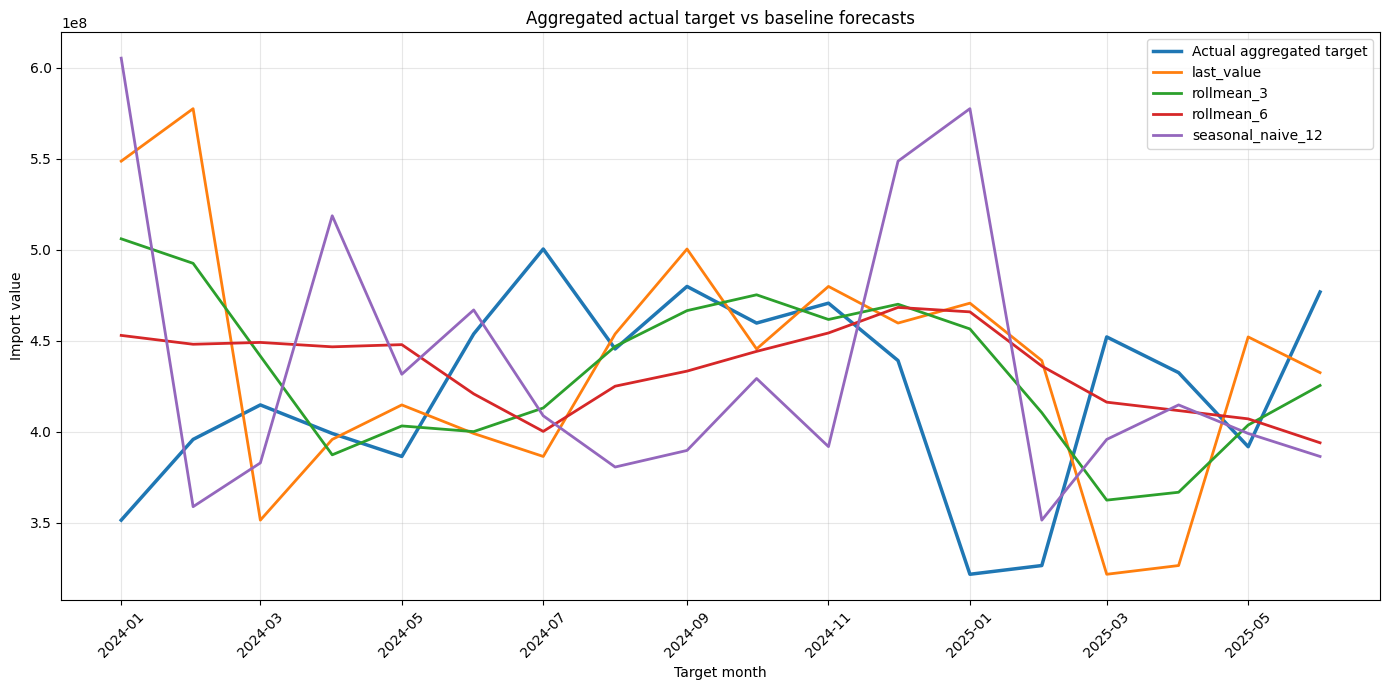

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# истинный агрегированный таргет берем один раз
actual_series = (
    agg_preds_h1[agg_preds_h1["model"] == "last_value"]
    [[target_date_col, "y_true"]]
    .sort_values(target_date_col)
)

plt.plot(
    actual_series[target_date_col],
    actual_series["y_true"],
    label="Actual aggregated target",
    linewidth=2.5
)

for model_name in agg_preds_h1["model"].unique():
    tmp = (
        agg_preds_h1[agg_preds_h1["model"] == model_name]
        .sort_values(target_date_col)
    )

    plt.plot(
        tmp[target_date_col],
        tmp["y_pred"],
        label=model_name,
        linewidth=2
    )

plt.title("Aggregated actual target vs baseline forecasts")
plt.xlabel("Target month")
plt.ylabel("Import value")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

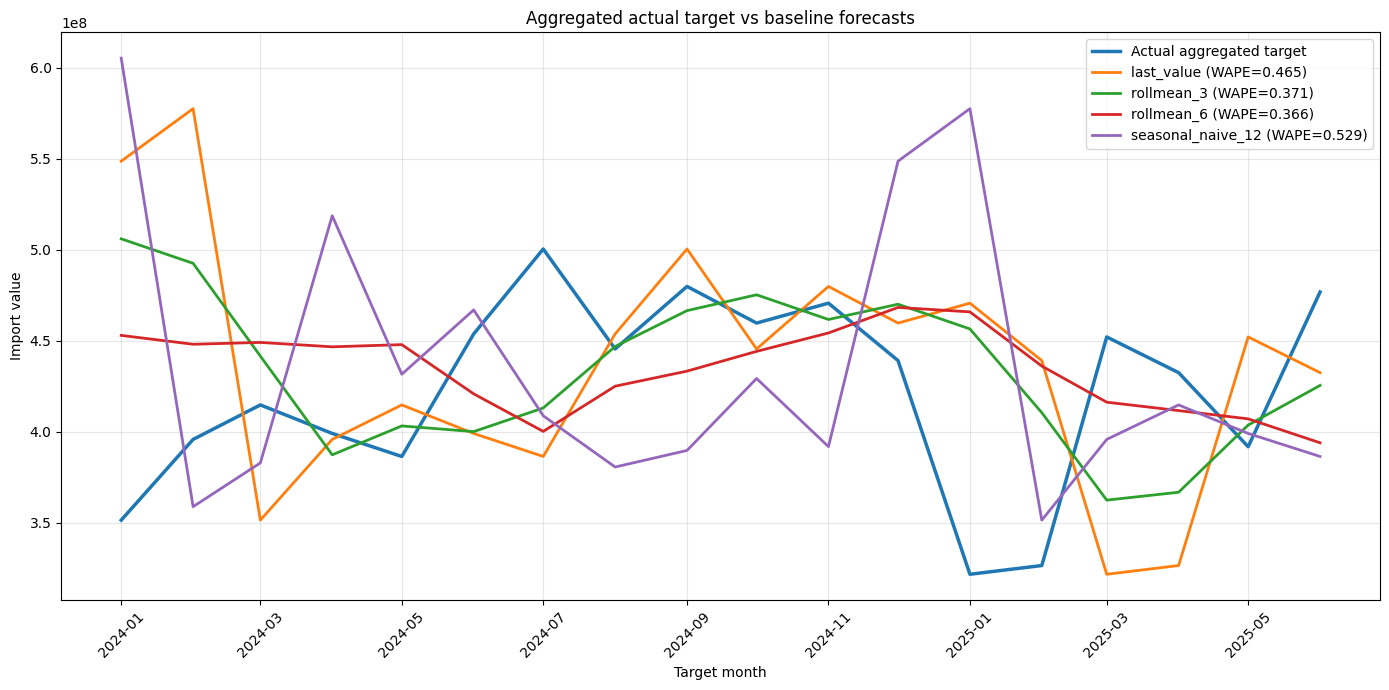

In [18]:
summary_map = baseline_summary_h1.set_index("model")["WAPE"].to_dict()

plt.figure(figsize=(14, 7))

actual_series = (
    agg_preds_h1[agg_preds_h1["model"] == "last_value"]
    [[target_date_col, "y_true"]]
    .sort_values(target_date_col)
)

plt.plot(
    actual_series[target_date_col],
    actual_series["y_true"],
    label="Actual aggregated target",
    linewidth=2.5
)

for model_name in agg_preds_h1["model"].unique():
    tmp = (
        agg_preds_h1[agg_preds_h1["model"] == model_name]
        .sort_values(target_date_col)
    )

    wape_val = summary_map.get(model_name, np.nan)

    plt.plot(
        tmp[target_date_col],
        tmp["y_pred"],
        label=f"{model_name} (WAPE={wape_val:.3f})",
        linewidth=2
    )

plt.title("Aggregated actual target vs baseline forecasts")
plt.xlabel("Target month")
plt.ylabel("Import value")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()